## **MFA Development**

### **Import Complete Subset of Database**

In [34]:
import pandas as pd

# file_path = '/home/shuyan/Research/PPM/GWR_filled_cnn.txt'
file_path = r'd:/Github/Data/data/GWR_filled_cnn_20241027.txt'
df = pd.read_csv(file_path)

# Now you can work with the DataFrame 'df'

C:\Users\xiong\AppData\Local\Temp\ipykernel_16216\872389488.py:5: DtypeWarning:

Columns (17,39,40) have mixed types. Specify dtype option on import or set low_memory=False.



In [35]:
df['building category'].value_counts()

building category
Building with exclusive residential use                                   1583510
Non-residential buildings                                                 1171508
Other residential buildings (residential buildings with secondary use)     212386
special construction                                                       113567
Building with partial residential use                                       87408
Temporary accommodation                                                      2648
Name: count, dtype: int64

In [37]:
df['building class'].value_counts()

building class
Building with one apartment                             1145979
Buildings with three or more apartments                  423145
Other buildings not otherwise specified                  340347
garage building                                          286058
Building with two apartments                             226290
tanks, silos and storage buildings                       127675
Farm buildings                                           122679
Other farm buildings                                     111827
industrial building                                       60386
Building for animal husbandry                             32397
office building                                           28515
wholesale and retail buildings                            15329
School and university buildings, research facilities      14641
Buildings for cultural and leisure purposes               11572
Churches and other cult buildings                          8278
hotel building           

In [ ]:
# Select categorical columns excluding those with '_status' in their names
categorical_columns = df.select_dtypes(include=['object']).columns

filtered_columns = [col for col in categorical_columns if '_status' not in col and col != 'official building number']

# Create a dictionary to store unique values for each column
unique_values = {col: df[col].unique() for col in filtered_columns}

# Find the maximum length of unique values to create a uniform table
max_len = max(len(values) for values in unique_values.values())

# Create a DataFrame to store the unique values table
unique_values_table = pd.DataFrame({col: pd.Series(values) for col, values in unique_values.items()})

# Display the unique values table
unique_values_table

In [ ]:
import pandas as pd
# test dataset read
# df = pd.read_csv('results_regression_1000_sample_test.csv')

In [14]:
# create a dictionary to map old values to new values
energy_source_mapping = {
    'fuel oil': 'oil',
    'natural gas': 'gas',
    'biogas': 'gas',
    'District heating share fossil ≤ 75%': 'district heating',
    'District heating share fossil ≤ 50% (waste heat)': 'district heating',
    'District heating share fossil ≤ 25%': 'district heating',
    'District heating Share fossil > 75%': 'district heating',
    'Electricity (NT)': 'electricity',
    'Electricity (MT)': 'electricity',
    'Electricity (HT)': 'electricity',
    'Electricity (production)': 'electricity',
    'electricity (heat pump)': 'electricity',
    'Thermal solar energy': 'solar energy',
    'wood pellets': 'wood',
    'wood chips': 'wood', 
    'Piece of wood': 'wood',
    'carbon bricks': 'other',
    'gas':'gas',
    'district heating (generic)':'district heating',
    'fuel oil': 'oil',
    'geothermal probe': 'geothermal',
    'Air': 'air',
    'wood (pellets)': 'wood',
    'wood (generic)': 'wood',
    'indefinite': 'other',
    'electricity': 'electricity',
    'earth register': 'geothermal',
    'geothermal (generic)': 'geothermal',
    'Other': 'other',
    'sun (thermal)': 'solar energy',
    'wood (chips)': 'wood',
    'Water (groundwater, surface water, waste water)': 'other',
    'District heating (high temperature)':'district heating',
    'District heating (low temperature)': 'district heating',
    'Waste heat (inside the building)':'other'
}

# List of columns to apply the mapping
columns_to_map = [
    'energy/heat source hot water 1', 'energy/heat source heating 1', 
    'energy/heat source hot water 2', 'energy/heat source heating 2'
]

# Apply the mapping to the specified columns
for column in columns_to_map:
    df[column] = df[column].replace(energy_source_mapping)

# create a dictionary to map old values to new values for heat generator hot water
heat_generator_mapping = {
    'boiler (generic)': 'boiler',
    'Central electric boiler': 'electric boiler',
    'heat pump': 'heat pump',
    'Boiler (generic) for a building': 'boiler',
    'No heat generator': 'no generator',
    'Heat exchangers (including for district heating)': 'heat exchanger',
    'Thermal solar system': 'solar system',
    'Electric storage central heating for a building': 'electric storage heating',
    'Boiler condensing for a building': 'condensing boiler',
    'Electric direct': 'electric direct',
    'Cogeneration plant for a building': 'cogeneration plant',
    'Combined heat and power plant': 'cogeneration plant',
    'Oven': 'oven',
    'Boiler non-condensing': 'non-condensing boiler',
    'Boilers non-condensing for a building': 'non-condensing boiler',
    'Boilers (generic) for multiple buildings': 'boiler',
    'Heat pump for several buildings': 'heat pump',
    'Condensing boilers for several buildings': 'condensing boiler',
    'Cogeneration plant for several buildings': 'cogeneration plant',
    'Thermal solar system for several buildings': 'solar system',
    'Other': 'other'
}

# List of columns to apply the heat generator mapping
heat_generator_columns = [
    'heat generator hot water 1', 'heat generator hot water 2',
    'heat generator heating 1', 'heat generator heating 2'
]

# Apply the heat generator mapping to the specified columns
for column in heat_generator_columns:
    df[column] = df[column].replace(heat_generator_mapping)

In [16]:
# drop columns with _status in their names
df = df.drop(columns=[col for col in df.columns if '_status' in col])

In [21]:
# uncapital all values in the columns for columns with "heat generator" in their names
df.loc[:, df.columns.str.contains('heat generator', case=False)] = df.loc[:, df.columns.str.contains('heat generator', case=False)].apply(lambda x: x.str.lower())
df['heat generator heating 1'].value_counts()

heat generator heating 1
boiler                                                                    1102404
heat pump for a building                                                   341389
no generator                                                               175765
oven                                                                       122358
electric storage heating                                                   118091
heat exchangers (including for district heating) for a building             72167
non-condensing boiler                                                       56335
condensing boiler                                                           41106
electric direct                                                             26419
heat pump                                                                   23179
heat exchangers (including for district heating) for several buildings       8065
solar thermal system for a building                                      

In [18]:
# Define a function to determine building system components based on energy source and heat generator
def get_system_components(energy_source, heat_generator):
    components = []
    
    if isinstance(energy_source, str) and isinstance(heat_generator, str): 
        if energy_source in ['oil', 'fuel oil']:
            components.append('radiators or underfloor heating')
            if 'boiler' in heat_generator:
                components.extend(['oil storage tank', 'oil delivery system', 'flue'])
            if 'condensing' in heat_generator:
                components.append('flue with condensing capability')
        
        if energy_source == 'gas':
            components.extend(['gas supply line', 'radiators or underfloor heating'])
            if 'boiler' in heat_generator or 'CHP' in heat_generator:
                components.append('flue')
            if 'condensing' in heat_generator:
                components.append('flue with condensing capability')
            if 'CHP' in heat_generator:
                components.extend(['CHP unit', 'electrical connection for power generation'])
        
        if energy_source == 'electricity':
            components.append('electrical connection')
            if 'electric boiler' in heat_generator:
                components.append('radiators or underfloor heating')
            if 'storage' in heat_generator:
                components.append('storage heater units')
        
        if energy_source == 'solar energy':
            components.extend(['solar collectors', 'storage tank', 'heat exchanger', 'radiators or underfloor heating'])
            if 'backup' in heat_generator:
                components.append('backup heating system')
        
        if energy_source == 'wood':
            components.extend(['wood storage', 'radiators or underfloor heating'])
            if 'boiler' in heat_generator:
                components.append('flue')
        
        if energy_source == 'geothermal':
            components.extend(['ground loop or boreholes', 'heat pump unit', 'electrical connection', 'radiators or underfloor heating'])
        
        if energy_source == 'district heating':
            components.extend(['connection to district heating network', 'heat exchanger unit', 'radiators or underfloor heating'])
            if 'backup' in heat_generator:
                components.append('backup heating system')
        
        if energy_source == 'other':
            components.append('heat exchanger unit')
        
    return components

# Apply the function to each row in the DataFrame
df['system_components_heating_1'] = df.apply(
    lambda row: get_system_components(row['energy/heat source heating 1'], row['heat generator heating 1']),
    axis=1
)

df['system_components_hot_water_1'] = df.apply(
    lambda row: get_system_components(row['energy/heat source hot water 1'], row['heat generator hot water 1']),
    axis=1
)

# Repeat for the second set of heating and hot water sources if necessary
df['system_components_heating_2'] = df.apply(
    lambda row: get_system_components(row['energy/heat source heating 2'], row['heat generator heating 2']),
    axis=1
)

df['system_components_hot_water_2'] = df.apply(
    lambda row: get_system_components(row['energy/heat source hot water 2'], row['heat generator hot water 2']),
    axis=1
)

In [ ]:
# Define the function to handle the boiler calculation
def has_boiler(row):
    if isinstance(row['heat generator heating 1'], str) and 'boiler' in row['heat generator heating 1']:
        return True
    if isinstance(row['heat generator hot water 1'], str) and 'boiler' in row['heat generator hot water 1']:
        return True
    return False

# define for heat pump
def has_heat_pump(row):
    if isinstance(row['heat generator heating 1'], str) and 'heat pump' in row['heat generator heating 1']:
        return True
    if isinstance(row['heat generator hot water 1'], str) and 'heat pump' in row['heat generator hot water 1']:
        return True
    return False

# To determine the availability of air ducts in buildings based on the provided data, we can use specific criteria related to the building category, building class, and the energy source/heat generator. Here's an enhanced approach:

# Building Category and Class: Certain building categories and classes are more likely to have central HVAC systems with air ducts. For example, non-residential buildings, large residential buildings, commercial buildings, and buildings with more than one apartment.
# Energy Source and Heat Generator: Buildings with specific energy sources and heat generators such as district heating, central electric boilers, heat pumps, and combined heat and power (CHP) systems are more likely to have air ducts.
# Criteria for Air Duct Availability
# We can set up a few rules to determine the likelihood of air ducts being present:

# Building categories like "commercial," "office," "hotel," "school," "university," "hospital," "wholesale and retail buildings," "sports halls," "cultural and leisure purposes," "short-term accommodation," "restaurants and bars," and "residential buildings with multiple apartments" are more likely to have air ducts.
# Building classes such as "Buildings with three or more apartments," "industrial building," "garage building," and "large residential buildings."
# Energy sources like "electricity," "district heating," "geothermal," "solar energy," and "central electric boiler" with corresponding heat generators.
# Modern buildings or those with certifications indicating high energy efficiency.

# Define a function to determine the availability of air ducts
def has_air_ducts(row):
    building_categories_with_ducts = [
        'commercial', 'office building', 'hotel building', 'school', 'university',
        'hospital', 'large residential building', 'wholesale and retail buildings',
        'sports halls', 'cultural and leisure purposes', 'short-term accommodation',
        'restaurants and bars', 'residential buildings with multiple apartments'
    ]
    
    building_classes_with_ducts = [
        'Buildings with three or more apartments', 'industrial building', 
        'garage building', 'large residential buildings'
    ]
    
    energy_sources_with_ducts = ['electricity', 'district heating', 'geothermal', 'solar energy']
    heat_generators_with_ducts = ['central heating', 'heat pump', 'central electric boiler', 'combined heat and power (CHP)']

    if row['building category'] in building_categories_with_ducts:
        return True
    if row['building class'] in building_classes_with_ducts:
        return True
    if row['energy/heat source heating 1'] in energy_sources_with_ducts:
        return True
    if row['heat generator heating 1'] in heat_generators_with_ducts:
        return True
    if row['energy/heat source heating 2'] in energy_sources_with_ducts:
        return True
    if row['heat generator heating 2'] in heat_generators_with_ducts:
        return True
    
    return False

# Apply the function to each row
df['has_air_ducts'] = df.apply(has_air_ducts, axis=1)

In [23]:
# export the results to a new CSV file
df.to_csv('results_before parametric model_20241105.csv', index=False)

### **Test on Predictive Mathematical Models**

In [85]:
# read the results
df = pd.read_csv(r'D:/Github/Data/results_before parametric model_20241105.csv')

C:\Users\xiong\AppData\Local\Temp\ipykernel_16216\3032347799.py:2: DtypeWarning:

Columns (17,39,40) have mixed types. Specify dtype option on import or set low_memory=False.



In [74]:
from HVAC import calculate_boiler_weight
from HVAC import estimate_boiler_materials
from HVAC import heat_pump_weight
from HVAC import estimate_heat_pump_materials
from HVAC import select_duct_material
from HVAC import calculate_HVAC_pipe_length
from HVAC import calculate_HVAC_pipe_weight
from HVAC import estimate_HVAC_pipe_materials
from HVAC import get_decade
from HVAC import estimate_radiator_by_building_age
from HVAC import estimate_materials_radiator

from plumbing import calculate_water_pipe_length_building
from plumbing import pipe_size_cm
from plumbing import calculate_water_pipe_weight
from plumbing import estimate_water_pipe_materials
from plumbing import select_pipe_material
# from plumbing import decide_pipe_size
from plumbing import calculate_num_bathroom
from plumbing import estimate_toilet_materials
from plumbing import estimate_sink_materials
from plumbing import estimate_shower_materials
from plumbing import estimate_bathtub_materials

from electrical import calculate_electrical_cable_length_per_apartment
# from electrical import calculate_electrical_cable_length_per_building
from electrical import calculate_electrical_cable_length
from electrical import calculate_electrical_cable_weight
from electrical import estimate_electrical_cable_materials

In [75]:
# # @ Raditor
# # calculate the number of radiators needed for each apartment
# def calculate_radiators_per_apartment(heated_area, num_rooms,num_kitchens): 
#     a = 1 # assume 1 radiator per room
#     # # calculate the heat loss rate based on the insulation level
#     # if insulation == "poor":
#     #     heat_loss_rate = 100
#     # elif insulation == "average":
#     #     heat_loss_rate = 80
#     # else:
#     #     heat_loss_rate = 60
#     heat_loss_rate = 80
#     # calculate the total heat loss for the property
#     total_heat_loss = heated_area * heat_loss_rate
#     radiator_capacity = 1500
#     # calculate the number of radiators needed based on the heating system's capacity
#     num_radiators = np.ceil(total_heat_loss / radiator_capacity)  # assuming a heating system capacity of 1.5 kW per radiator

#     # calculate the total number of radiators needed
#     # assume 1 radiator per bedroom, bathroom, living room and kitchen
#     total_num_radiators = a * num_rooms + num_kitchens
#     return int(np.max([total_num_radiators, num_radiators])) # round up the number of radiators to the nearest integer


# Radiator data by decade
radiator_data = {
    '1930s and below': {'type': 'no radiator', 'material': 'cast iron', 'unit_weight': 0, 'lifespan': 20},
    '1940s': {'type': 'cast iron radiator', 'material': 'cast iron', 'unit_weight': 63, 'lifespan': 20},
    '1950s': {'type': 'steel panel radiator', 'material': 'steel', 'unit_weight': 21, 'lifespan': 50},
    '1960s': {'type': 'convector radiator', 'material': 'steel', 'unit_weight': 42, 'lifespan': 30},
    '1970s': {'type': 'column radiator', 'material': 'cast iron', 'unit_weight': 82, 'lifespan': 50},
    '1980s': {'type': 'steel panel radiator', 'material': 'steel', 'unit_weight': 21, 'lifespan': 50},
    '1990s': {'type': 'low surface temperature (LST) radiator', 'material': 'steel', 'unit_weight': 38, 'lifespan': 50},
    '2000s and beyond': {'type': 'low surface temperature (LST) radiator', 'material': 'steel', 'unit_weight': 38, 'lifespan': 50}
}

# Material composition for each radiator type
radiator_material_composition = {
    'cast iron radiator': {'cast iron': 0.95, 'plastic': 0.05},
    'steel panel radiator': {'steel': 0.85, 'plastic': 0.05, 'copper': 0.1},
    'convector radiator': {'steel': 0.8, 'copper': 0.15, 'plastic': 0.05},
    'column radiator': {'cast iron': 0.90, 'plastic': 0.05, 'copper': 0.05},
    'low surface temperature (LST) radiator': {'steel': 0.75, 'copper': 0.15, 'plastic': 0.1}
}


# # Function to calculate the decade based on building year
# def get_decade(building_year):
#     # Use formula to calculate the starting year of the decade
#     decade_start = (building_year // 10) * 10
#     return f"{decade_start}s"

# # Function to determine the decade based on the specific building year
# def get_decade(building_year):
#     if building_year < 1940:
#         return '1930s and below'
#     if 1940 <= building_year < 1950:
#         return '1940s'
#     elif 1950 <= building_year < 1960:
#         return '1950s'
#     elif 1960 <= building_year < 1970:
#         return '1960s'
#     elif 1970 <= building_year < 1980:
#         return '1970s'
#     elif 1980 <= building_year < 1990:
#         return '1980s'
#     elif 1990 <= building_year < 2000:
#         return '1990s'
#     else:  # for 2000 and beyond
#         return '2000s and beyond' # For buildings built in or after 2010
    
# # Function to estimate material distribution based on radiator type
# def estimate_materials_radiator(weight_kg, radiator_type):
#     if radiator_type not in radiator_material_composition:
#         raise ValueError(f"Radiator type {radiator_type} is not in the material composition database.")
    
#     # Get the material composition for the given radiator type
#     material_pct = radiator_material_composition[radiator_type]
    
#     # Calculate estimated material weights based on percentages
#     material_weights = {material: weight_kg * pct for material, pct in material_pct.items()}
    
#     return material_weights


# # Function to determine the radiator type and estimate materials based on building age
# def estimate_radiator_by_building_age(building_year, weight_kg):
#     # Get the decade based on building year using the new formula
#     decade = get_decade(building_year)
    
#     # Check if the decade is in the radiator data
#     if decade not in radiator_data:
#         raise ValueError(f"Radiator data for the decade {decade} is not available.")
    
#     # Get radiator type based on the decade
#     radiator_type = radiator_data[decade]['type']
    
#     # Check if the radiator type is "no radiator" and return zero weights if true
#     if radiator_type == "no radiator":
#         return radiator_type, {'total_weight': 0}  # or return an empty dict or None as desired
    
#     # Estimate material distribution for the determined radiator type
#     material_weights = estimate_materials_radiator(weight_kg, radiator_type)
    
#     return radiator_type, material_weights



In [86]:
# remove installation year if smaller than construction year
df['2iInst./Renov. heating system'] = df[['2iInst./Renov. heating system','year of construction of the building yyyy']].max(axis=1)
df['2hInst./Renov. hot water supply'] = df[['2hInst./Renov. hot water supply','year of construction of the building yyyy']].max(axis=1)

In [87]:
# Approximate weights for each type of fixture in kilograms
weight_per_toilet = 25      # kg
weight_per_shower = 50      # kg
weight_per_sink = 15      # kg
weight_per_bathtub = 100     # kg

# @ air ducts
width = 0.5  # in meters
height = 0.3  # in meters
outer_diameter = 0.5  # in meters (for circular ducts)
wall_thickness = 0.001  # in meters (1 mm)
 
for index, row in df.iterrows():

    # Residential Building
    num_residents = row['9aNumber of residents (EFH/ MFH)'] # need double check
    num_floors = row['number of floors']
    building_height = row['height']
    building_area = row['building area']
    building_age = row['year of construction of the building yyyy']
    # heating system age
    system_age = row['2iInst./Renov. heating system']
    floor_height = building_height/num_floors if num_floors > 0 else 0

    # @ radiator        
    # # Assign 0 radiators for buildings constructed after 2020 and before 1940
    # if system_age > 2020 or system_age < 1940:
    #     df.loc[index, 'radiator weight'] = 0
    #     df.loc[index, 'radiator material weights'] = [0]  # or set to None or an empty list as needed
    #     continue  # Skip to the next row in the DataFrame
    
    if 'radiators or underfloor heating' in row['system_components_heating_1']:
        # assuming 12 kg example weight in kilograms for single radiator
        radiator_unit_weight_kg = radiator_data[get_decade(system_age)]['unit_weight']  # Get unit weight based on building year
        num_radiator = row['number of radiators']
                # Check if number of radiators is zero
        if num_radiator <= 0:
            df.loc[index, 'radiator weight'] = 0
            df.loc[index, 'radiator material weights'] = [0]  # or set to None or an empty list as needed
            continue  # Skip to the next row in the DataFrame
        
        total_radiator_weight = num_radiator * radiator_unit_weight_kg
        
        # Ensure the decade exists in radiator_data
        decade = get_decade(building_age)
        if decade in radiator_data:
            radiator_type, material_weights = estimate_radiator_by_building_age(system_age, radiator_unit_weight_kg)
            df.loc[index, 'radiator weight'] = total_radiator_weight
            df.loc[index, 'radiator material weights'] = [material_weights]
        else:
            # Handle the case where radiator data for the decade is not available
            df.loc[index, 'radiator weight'] = 0
            df.loc[index, 'radiator material weights'] = [0]  

        radiator_type, material_weights = estimate_radiator_by_building_age(system_age, radiator_unit_weight_kg)
        # # radiator_material_weights = estimate_materials_radiator(total_radiator_weight) 
        # df.loc[index, 'radiator weight'] = total_radiator_weight
        # df.loc[index, 'radiator material weights'] = [material_weights]
        # Adjusting assignments in the loop
        df.loc[index, 'radiator weight'] = total_radiator_weight if decade in radiator_data else 0
        df.loc[index, 'radiator material weights'] = [material_weights] if decade in radiator_data else [0]

        
    # @ boiler
    if has_boiler(row):
        # Calculate boiler
        num_boilers=1
        # assumption: https://heatable.co.uk/boiler-advice/what-size-boiler-for-my-home
        # system boiler or conventional boiler
        total_num_rooms = row['number of rooms']
        num_radiator = row['number of radiators']
        boiler_material_weights = estimate_boiler_materials(calculate_boiler_weight(num_radiator))
        df.loc[index,'boiler material weights'] = [boiler_material_weights]
    
    # @ heat pump 
    if has_heat_pump(row):
        # Calculate heat pump
        # https://www.energysavingtrust.org.uk/heat-pumps/heat-pump-sizing
        heat_pump = heat_pump_weight(building_area)
        heat_pump_material_weights = estimate_heat_pump_materials(heat_pump)
        df.loc[index,'heat pump material weights'] = [heat_pump_material_weights]

    # @ air ducts
    # if 'air ducts' in row['has_air_ducts']:
    if row['has_air_ducts']:        

        # Select duct material based on building year
        material, density, material_pct = select_duct_material(building_age)
        total_duct_length_horizontal = row['air duct length']
        HVAC_pipe_total_length = calculate_HVAC_pipe_length(floor_height, total_duct_length_horizontal, building_area, num_floors)
        # HVAC_pipe_weight = calculate_HVAC_pipe_weight(HVAC_pipe_total_length, width, height, outer_diameter, wall_thickness, density, is_rectangular=True)
        HVAC_pipe_weight = calculate_HVAC_pipe_weight(HVAC_pipe_total_length, density)
        HVAC_pipe_material_weights = estimate_HVAC_pipe_materials(HVAC_pipe_weight, material_pct)
        # Calculate weight of a pipe assuming it is rectangular
        # https://www.ductstore.co.uk/acatalog/350x150mm.html#aRDS350_2d150
        # assume steel pipe, kg/m^3 for steel
        df.loc[index, 'air duct total length in m'] = HVAC_pipe_total_length
        df.loc[index,'air duct material weights'] = [HVAC_pipe_material_weights]

    # @ water pipes
    # Select pipe material based on construction year
    material, density = select_pipe_material(building_age)
    # Assume typical dimensions for the selected material
    if material == "copper":
        diameter = 2.54  # in cm
        wall_thickness = 0.165  # in cm
    elif material == "pex":
        diameter = 1.6  # in cm
        wall_thickness = 0.2  # in cm
    elif material == "galvanized steel":
        diameter = 2.54  # in cm
        wall_thickness = 0.15  # in cm
        
    length_water_pipe_horizontal = row['water pipe length']
    water_pipe_length = calculate_water_pipe_length_building(length_water_pipe_horizontal, num_floors, floor_height, building_area)
    water_pipe_size = pipe_size_cm(num_residents, num_floors)
    # Calculate pipe weight
    water_pipe_weight = calculate_water_pipe_weight(water_pipe_length, density, min(water_pipe_size,diameter), wall_thickness)
    pipe_type = material
    water_pipe_material_weights = estimate_water_pipe_materials(water_pipe_weight, pipe_type)
    df.loc[index, 'water pipe length in m'] = water_pipe_length
    df.loc[index, 'water pipe material weights'] = [water_pipe_material_weights]

    # @ electrical wires
    total_cable_length_horizontal = row['electrical cable length']
    electrical_wire_length = calculate_electrical_cable_length(floor_height, total_cable_length_horizontal, num_floors)
    electrical_wire_copper_weight = calculate_electrical_cable_weight(electrical_wire_length, density=270.48/1000)
    electrical_wire_material_weights = estimate_electrical_cable_materials(electrical_wire_copper_weight)
    df.loc[index,'electrical cable material weights'] = [electrical_wire_material_weights]

    # @ plumbing fixtures
    # Calculate plumbing fixtures
    num_bathrooms = calculate_num_bathroom(total_num_rooms)   
    # Number of each fixture per bathroom
    num_toilets = num_bathrooms
    num_showers = num_bathrooms
    num_sinks = num_bathrooms
    num_bathtubs = num_bathrooms

    toilet_material_weights = estimate_toilet_materials(num_toilets, weight_per_toilet)
    df.loc[index,'toilet material weights'] = [toilet_material_weights]
    
    shower_material_weights = estimate_shower_materials(num_showers, weight_per_shower)
    df.loc[index,'shower material weights'] = [shower_material_weights]
    
    sink_material_weights = estimate_sink_materials(num_sinks, weight_per_sink)
    df.loc[index,'sink material weights'] = [sink_material_weights]
    
    bathtub_material_weights = estimate_bathtub_materials(num_bathtubs, weight_per_bathtub)
    df.loc[index,'bathtub material weights'] = [bathtub_material_weights]


C:\Users\xiong\AppData\Local\Temp\ipykernel_16216\3033164830.py:97: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '(53.330378358980205+2.3j)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

C:\Users\xiong\AppData\Local\Temp\ipykernel_16216\3033164830.py:121: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '(143.4212611966007+2.3j)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



In [ ]:
# Identify columns with complex data types
complex_columns = df.select_dtypes(include=['complex128']).columns

# Convert complex columns to float by taking only the real part
for col in complex_columns:
    df[col] = df[col].apply(lambda x: x.real if x.imag == 0 else x).astype('float64')


c:\Users\xiong\anaconda3\envs\myenv\lib\site-packages\pandas\core\dtypes\astype.py:134: ComplexWarning:

Casting complex values to real discards the imaginary part

c:\Users\xiong\anaconda3\envs\myenv\lib\site-packages\pandas\core\dtypes\astype.py:134: ComplexWarning:

Casting complex values to real discards the imaginary part



,federal building identifier,canton abbreviation,building status,e building coordinate,n building coordinate,origin of coordinates,building category,building area,building class,area,perimeter,height,energy/heat source hot water 1,heat generator hot water 1,energy/heat source heating 1,heat generator heating 1,number of floors,official building number,living space,number of rooms,cooking equipment,multi-storey apartment,floor,number of radiators,air duct length,water pipe length,number of toilets,number of sink,number of shower,number of bathtub,electrical cable length,number of apartments,year of construction of the building yyyy,energy/heat source hot water 2,heat generator hot water 2,energy/heat source heating 2,heat generator heating 2,energy reference area,building volume,18Construction building,19Floor plan type,2iInst./Renov. heating system,5Area-related outside air volume flow V/AE,year of demolition of the building,9aNumber of residents (EFH/ MFH),2hInst./Renov. hot water supply,system_components_heating_1,system_components_hot_water_1,system_components_heating_2,system_components_hot_water_2,has_air_ducts,radiator weight,radiator material weights,boiler material weights,air duct total length in m,air duct material weights,water pipe length in m,water pipe material weights,electrical cable material weights,toilet material weights,shower material weights,sink material weights,bathtub material weights,heat pump material weights
0,5515,ZH,building demolished,2674487.379,1235782.062,901.0,Building with exclusive residential use,189.0,Buildings with three or more apartments,191.531197,65.110690,6.75,oil,boiler,oil,boiler,3.0,434,265.0,11.0,3.0,0.0,3101.0,16.0,51.798853,159.868696,5.0,5.0,5.0,5.0,1294.971330,3.0,2021.0,NaN,NaN,NaN,NaN,292.0,NaN,difficult,compact,2021.0,0.7,2022.0,5.0,2021.0,"['radiators or underfloor heating', 'oil stora...","['radiators or underfloor heating', 'oil stora...",[],[],True,608.0,"[{'steel': 28.5, 'copper': 5.7, 'plastic': 3.8...","[{'steel': 48.525000000000006, 'copper': 6.470...",106.713453,"[{'plastic': 162.20444931186648, 'steel': 40.5...",230.993772,[{'pex': 19.10011705352409}],"[{'copper': 10.175065606767646, 'pvc': 396.827...","[{'porcelain': 106.25, 'plastic': 12.5, 'stain...","[{'glass': 125.0, 'plastic': 75.0, 'stainless ...","[{'porcelain': 52.5, 'plastic': 15.0, 'stainle...","[{'acrylic': 400.0, 'plastic': 50.0, 'cast iro...",NaN
1,22736,ZH,building demolished,2687809.748,1258657.005,901.0,Other residential buildings (residential build...,360.0,Building with one apartment,360.469437,84.366491,5.79,electricity,electric boiler,wood,boiler,3.0,162,302.0,9.0,1.0,1.0,3100.0,17.0,78.201662,191.159619,4.0,4.0,4.0,4.0,1955.041560,1.0,1928.0,NaN,NaN,NaN,NaN,NaN,NaN,medium,stretched,2021.0,0.7,2021.0,20.0,2021.0,"['wood storage', 'radiators or underfloor heat...","['electrical connection', 'radiators or underf...",[],[],False,646.0,"[{'steel': 28.5, 'copper': 5.7, 'plastic': 3.8...","[{'steel': 49.762499999999996, 'copper': 6.635...",NaN,NaN,276.789994,"[{'steel': 242.26700471383538, 'zinc coating':...","[{'copper': 15.293039234388417, 'pvc': 596.428...","[{'porcelain': 85.0, 'plastic': 10.0, 'stainle...","[{'glass': 100.0, 'plastic': 60.0, 'stainless ...","[{'porcelain': 42.0, 'plastic': 12.0, 'stainle...","[{'acrylic': 320.0, 'plastic': 40.0, 'cast iro...",NaN
2,57265,ZH,building demolished,2683272.988,1242653.227,901.0,Building with exclusive residential use,133.0,Building with one apartment,92.916490,39.992589,6.59,gas,boiler,gas,boiler,3.0,1083,150.0,5.0,1.0,1.0,3100.0,8.0,30.618622,85.732141,2.0,2.0,2.0,2.0,765.465545,1.0,1941.0,No,no generator,No,no generator,NaN,NaN,difficult,compact,2021.0,0.7,2021.0,9.0,2021.0,"['gas supply line', 'radiators or underfloor h...","['gas supply line', 'radiators or underfloor h...",[],[],False,304.0,"[{'steel': 28.5, 'copper': 5.7, 'plastic': 3.8...","[{'steel': 38.625, 'copper': 5.15, 'plastic': ...",NaN,NaN,140.273856,"[{'steel': 122.7780184532742, 

In [103]:

# count Nan values of specific column
df['building category'].isnull().sum()

827

In [94]:
# export the results to a new CSV file
df.to_csv(r'D:/Github/Data/data/calculated_data_20241112.txt', index=False)

In [ ]:
import pandas as pd 
# read the updated DataFrame from the CSV file
# df = pd.read_csv('/media/shuyan/Local Disk (D:)/Github/Data/calculated_data.txt')
# df = pd.read_csv('D:/Github/Data/calculated_data.txt')
df = pd.read_csv('D:/Github/Data/data/calculated_data_20241112.txt')

C:\Users\xiong\AppData\Local\Temp\ipykernel_16216\3872314630.py:5: DtypeWarning:

Columns (18,40,41,64) have mixed types. Specify dtype option on import or set low_memory=False.



In [97]:
df_chunk = df

# Select all columns that contain the phrase 'material weights' in their names
material_columns = df_chunk.filter(like='material weights').columns.tolist()

# Temporary DataFrame to store all expanded columns
expanded_columns_df = pd.DataFrame(index=df_chunk.index)

for col in material_columns:
    if col in df_chunk.columns:
        # Expand each dictionary or list in the column into separate columns
        expanded_df = df_chunk[col].apply(
            lambda x: pd.Series(x[0]) if isinstance(x, list) and len(x) > 0 else 
            (pd.Series(x) if isinstance(x, dict) else pd.Series())
        )
        
        # Rename columns to include the component's name for clarity
        expanded_df = expanded_df.add_suffix(f'_{col}')
        
        # Concatenate expanded columns back to the main DataFrame
        df_chunk = pd.concat([df_chunk, expanded_df], axis=1)
        
        # Drop the original column after expansion
        df_chunk = df_chunk.drop(columns=[col])

# Fill NaNs with 0 only in the expanded columns
df_chunk[expanded_columns_df.columns] = df_chunk[expanded_columns_df.columns].fillna(0)

df_material_weights = df_chunk
df_material_weights

,federal building identifier,canton abbreviation,building status,e building coordinate,n building coordinate,origin of coordinates,building category,building area,building class,area,perimeter,height,energy/heat source hot water 1,heat generator hot water 1,energy/heat source heating 1,heat generator heating 1,number of floors,official building number,living space,number of rooms,cooking equipment,multi-storey apartment,floor,number of radiators,air duct length,water pipe length,number of toilets,number of sink,number of shower,number of bathtub,electrical cable length,number of apartments,year of construction of the building yyyy,energy/heat source hot water 2,heat generator hot water 2,energy/heat source heating 2,heat generator heating 2,energy reference area,building volume,18Construction building,19Floor plan type,2iInst./Renov. heating system,5Area-related outside air volume flow V/AE,year of demolition of the building,9aNumber of residents (EFH/ MFH),2hInst./Renov. hot water supply,system_components_heating_1,system_components_hot_water_1,system_components_heating_2,system_components_hot_water_2,has_air_ducts,radiator weight,air duct total length in m,water pipe length in m,steel_radiator material weights,copper_radiator material weights,plastic_radiator material weights,cast iron_radiator material weights,total_weight_radiator material weights,0_radiator material weights,steel_boiler material weights,copper_boiler material weights,plastic_boiler material weights,mineral wool_boiler material weights,aluminum_boiler material weights,brass_boiler material weights,other electronics_boiler material weights,plastic_air duct material weights,steel_air duct material weights,mineral wool_air duct material weights,aluminum_air duct material weights,polyurethane foam_air duct material weights,fiberglass_air duct material weights,pex_water pipe material weights,steel_water pipe material weights,zinc coating_water pipe material weights,copper_water pipe material weights,copper_electrical cable material weights,pvc_electrical cable material weights,porcelain_toilet material weights,plastic_toilet material weights,stainless steel_toilet material weights,glass_shower material weights,plastic_shower material weights,stainless steel_shower material weights,porcelain_sink material weights,plastic_sink material weights,stainless steel_sink material weights,acrylic_bathtub material weights,plastic_bathtub material weights,cast iron_bathtub material weights,steel_heat pump material weights,aluminum_heat pump material weights,copper_heat pump material weights,plastic_heat pump material weights,refrigerant_heat pump material weights
0,5515,ZH,building demolished,2674487.379,1235782.062,901.0,Building with exclusive residential use,189.0,Buildings with three or more apartments,191.531197,65.110690,6.75,oil,boiler,oil,boiler,3.0,434,265.0,11.0,3.0,0.0,3101.0,16.0,51.798853,159.868696,5.0,5.0,5.0,5.0,1294.971330,3.0,2021.0,NaN,NaN,NaN,NaN,292.0,NaN,difficult,compact,2021.0,0.7,2022.0,5.0,2021.0,"['radiators or underfloor heating', 'oil stora...","['radiators or underfloor heating', 'oil stora...",[],[],True,608.0,106.713453,230.993772,28.5,5.7,3.8,NaN,NaN,NaN,48.5250,6.470,3.2350,3.2350,1.294,1.294,0.6470,162.204449+ 0.000000j,40.551112+ 0.000000j,NaN+ 0.00000j,NaN+0.0j,NaN+0.0j,NaN+0.0j,19.100117+ 0.000000j,NaN+ 0.000000j,NaN+0.000000j,NaN+ 0.000000j,10.175066,396.827559,106.25,12.5,6.25,125.0,75.0,50.0,52.5,15.0,7.5,400.0,50.0,50.0,NaN,NaN,NaN,NaN,NaN
1,22736,ZH,building demolished,2687809.748,1258657.005,901.0,Other residential buildings (residential build...,360.0,Building with one apartment,360.469437,84.366491,5.79,electricity,electric boiler,wood,boiler,3.0,162,302.0,9.0,1.0,1.0,3100.0,17.0,78.201662,191.159619,4.0,4.0,4.0,4.0,1955.041560,1.0,1928.0,NaN,NaN,NaN,NaN,NaN,NaN,medium,stretched,2021.0,0.7,2021.0,20.0,2021.0,"['wood storage', 'radiators or underfloor heat...","['electrical connection', 'radiators or underf...",[],[],False,646.0

In [ ]:
# Identify columns with complex data types
complex_columns = df_material_weights.select_dtypes(include=['complex128']).columns

# Convert complex columns to float by taking only the real part
for col in complex_columns:
    df_material_weights[col] = df_material_weights[col].apply(lambda x: x.real if x.imag == 0 else x).astype('float64')


c:\Users\xiong\anaconda3\envs\myenv\lib\site-packages\pandas\core\dtypes\astype.py:134: ComplexWarning:

Casting complex values to real discards the imaginary part

c:\Users\xiong\anaconda3\envs\myenv\lib\site-packages\pandas\core\dtypes\astype.py:134: ComplexWarning:

Casting complex values to real discards the imaginary part

c:\Users\xiong\anaconda3\envs\myenv\lib\site-packages\pandas\core\dtypes\astype.py:134: ComplexWarning:

Casting complex values to real discards the imaginary part

c:\Users\xiong\anaconda3\envs\myenv\lib\site-packages\pandas\core\dtypes\astype.py:134: ComplexWarning:

Casting complex values to real discards the imaginary part

c:\Users\xiong\anaconda3\envs\myenv\lib\site-packages\pandas\core\dtypes\astype.py:134: ComplexWarning:

Casting complex values to real discards the imaginary part

c:\Users\xiong\anaconda3\envs\myenv\lib\site-packages\pandas\core\dtypes\astype.py:134: ComplexWarning:

Casting complex values to real discards the imaginary part

c:\Users\x

,federal building identifier,canton abbreviation,building status,e building coordinate,n building coordinate,origin of coordinates,building category,building area,building class,area,perimeter,height,energy/heat source hot water 1,heat generator hot water 1,energy/heat source heating 1,heat generator heating 1,number of floors,official building number,living space,number of rooms,cooking equipment,multi-storey apartment,floor,number of radiators,air duct length,water pipe length,number of toilets,number of sink,number of shower,number of bathtub,electrical cable length,number of apartments,year of construction of the building yyyy,energy/heat source hot water 2,heat generator hot water 2,energy/heat source heating 2,heat generator heating 2,energy reference area,building volume,18Construction building,19Floor plan type,2iInst./Renov. heating system,5Area-related outside air volume flow V/AE,year of demolition of the building,9aNumber of residents (EFH/ MFH),2hInst./Renov. hot water supply,system_components_heating_1,system_components_hot_water_1,system_components_heating_2,system_components_hot_water_2,has_air_ducts,radiator weight,air duct total length in m,water pipe length in m,steel_radiator material weights,copper_radiator material weights,plastic_radiator material weights,cast iron_radiator material weights,total_weight_radiator material weights,0_radiator material weights,steel_boiler material weights,copper_boiler material weights,plastic_boiler material weights,mineral wool_boiler material weights,aluminum_boiler material weights,brass_boiler material weights,other electronics_boiler material weights,plastic_air duct material weights,steel_air duct material weights,mineral wool_air duct material weights,aluminum_air duct material weights,polyurethane foam_air duct material weights,fiberglass_air duct material weights,pex_water pipe material weights,steel_water pipe material weights,zinc coating_water pipe material weights,copper_water pipe material weights,copper_electrical cable material weights,pvc_electrical cable material weights,porcelain_toilet material weights,plastic_toilet material weights,stainless steel_toilet material weights,glass_shower material weights,plastic_shower material weights,stainless steel_shower material weights,porcelain_sink material weights,plastic_sink material weights,stainless steel_sink material weights,acrylic_bathtub material weights,plastic_bathtub material weights,cast iron_bathtub material weights,steel_heat pump material weights,aluminum_heat pump material weights,copper_heat pump material weights,plastic_heat pump material weights,refrigerant_heat pump material weights
0,5515,ZH,building demolished,2674487.379,1235782.062,901.0,Building with exclusive residential use,189.0,Buildings with three or more apartments,191.531197,65.110690,6.75,oil,boiler,oil,boiler,3.0,434,265.0,11.0,3.0,0.0,3101.0,16.0,51.798853,159.868696,5.0,5.0,5.0,5.0,1294.971330,3.0,2021.0,NaN,NaN,NaN,NaN,292.0,NaN,difficult,compact,2021.0,0.7,2022.0,5.0,2021.0,"['radiators or underfloor heating', 'oil stora...","['radiators or underfloor heating', 'oil stora...",[],[],True,608.0,106.713453,230.993772,28.5,5.7,3.8,NaN,NaN,NaN,48.5250,6.470,3.2350,3.2350,1.294,1.294,0.6470,162.204449,40.551112,NaN,NaN,NaN,NaN,19.100117,NaN,NaN,NaN,10.175066,396.827559,106.25,12.5,6.25,125.0,75.0,50.0,52.5,15.0,7.5,400.0,50.0,50.0,NaN,NaN,NaN,NaN,NaN
1,22736,ZH,building demolished,2687809.748,1258657.005,901.0,Other residential buildings (residential build...,360.0,Building with one apartment,360.469437,84.366491,5.79,electricity,electric boiler,wood,boiler,3.0,162,302.0,9.0,1.0,1.0,3100.0,17.0,78.201662,191.159619,4.0,4.0,4.0,4.0,1955.041560,1.0,1928.0,NaN,NaN,NaN,NaN,NaN,NaN,medium,stretched,2021.0,0.7,2021.0,20.0,2021.0,"['wood storage', 'radiators or underfloor heat...","['electrical connection', 'radiators or underf...",[],[],False,646.0,NaN,276.789994,28.5,5.7,3.8,NaN,NaN,NaN,49.7625,6.635,3.3175,3.3175,1.327,1.327,0.6635,Na

In [99]:
# Save the updated DataFrame to a new CSV file
# df_expanded.to_csv('/media/shuyan/Local Disk (D:)/Github/Data/material_weight_data_0723.txt')
df_material_weights.to_csv('d:/Github/Data/data/material_weight_data_20241112.txt')

## **MFA Development**

In [53]:
df_BS = pd.read_csv('building_category_building_system_matrix.csv')
df_BS = df_BS.dropna(axis=1, how='all')
# restructure the imported dataframe

# Melt the dataframe
melted_df = pd.melt(df_BS, id_vars=['building system','sub system' ,'component'], var_name='building category', value_name='has_component')

# Filter the rows where the component is present
filtered_df = melted_df[melted_df['has_component'] == True].drop('has_component', axis=1)

# Print the result
filtered_df= filtered_df[['building category', 'building system', 'sub system','component']]
filtered_df

# Load the two dataframes
df1 = filtered_df

# Get the unique component names
component_names = df1['component'].unique()

# column_dict = {}
# for component in component_names:
#     # if not component.startswith('insulation'):
#         columns = [col for col in df2.columns if component in col]
#         column_dict[component] = columns
component_names
# Initialize a dictionary to hold materials for each component
component_materials = {}

# Iterate through columns to find material weights columns
for col in df.columns:
    if 'material weights' in col:
        # Extract the component name from the column name
        component = None
        for name in component_names:
            if col.startswith(name):
                component = name
                break
        if component is not None:
            # Initialize a set to hold unique materials for this component
            materials = set()
            for value in df[col]:
                if isinstance(value, list):  # Ensure value is a list
                    for item in value:
                        if isinstance(item, dict):  # Ensure item is a dictionary
                            materials.update(item.keys())
            # Add an entry to the dictionary for this component
            component_materials[component] = list(materials)

# Print the result
print(component_materials)

{'radiator': ['plastic', 'total_weight', 'copper', 'cast iron', 'steel'], 'boiler': ['other electronics', 'plastic', 'copper', 'steel', 'mineral wool', 'brass', 'aluminum'], 'air duct': ['plastic', 'steel', 'polyurethane foam', 'mineral wool', 'fiberglass', 'aluminum'], 'water pipe': ['steel', 'copper', 'pex', 'zinc coating'], 'electrical cable': ['copper', 'pvc'], 'toilet': ['stainless steel', 'porcelain', 'plastic'], 'shower': ['stainless steel', 'glass', 'plastic'], 'sink': ['stainless steel', 'porcelain', 'plastic'], 'bathtub': ['cast iron', 'acrylic', 'plastic'], 'heat pump': ['plastic', 'copper', 'refrigerant', 'steel', 'aluminum']}


In [ ]:
import pandas as pd
# read the data from the file
# df_material_weights = pd.read_csv('/media/shuyan/Local Disk (D:)/Github/Data/material_weight_data_0723.txt')
# df_material_weights = pd.read_csv('d:/Github/Data/data/material_weight_data_20241031.txt')
# df_material_weights = pd.read_csv('d:/Github/Data/material_weight_data_0723.txt')

In [ ]:
# # save component materials to a dictionary
# component_materials = {'radiator': ['cast iron', 'copper', 'steel', 'plastic'], 'boiler': ['mineral wool', 'brass', 'copper', 'steel', 'aluminum', 'plastic', 'other electronics'], 'water pipe': ['copper', 'zinc coating', 'pex', 'steel'], 'electrical cable': ['pvc', 'copper'], 'toilet': ['porcelain', 'stainless steel', 'plastic'], 'shower': ['plastic', 'glass', 'stainless steel'], 'sink': ['porcelain', 'stainless steel', 'plastic'], 'bathtub': ['plastic', 'acrylic', 'cast iron'], 'air duct': ['fiberglass', 'mineral wool', 'steel', 'aluminum', 'plastic', 'polyurethane foam'], 'heat pump': ['copper', 'steel', 'aluminum', 'refrigerant', 'plastic']}
# # union of all materials from component_materials values
# all_materials = set()
# for materials in component_materials.values():
#     all_materials.update(materials)
# # transform the type of all_materials from dict to list
# all_materials = list(all_materials)
# all_materials

In [55]:
# df3 = df1
# column_dict = component_materials

# for index, row in df3.iterrows():
#     # Iterate over the keys of the dictionary
#     for component in column_dict.keys():
#         # Check if the component exists in the dataframe
#         if component == row['component']:
#             for value in column_dict[row['component']]:
#                 new_row = pd.DataFrame({ 'building category': [row['building category']], 'building system': [row['building system']], 'sub system': [row['sub system']],'component': [row['component']], 'item': value})
#                 df3 = df3.append(new_row, ignore_index=True)

# df3=df3.sort_values(by=['building category','building system','sub system','component']).dropna()
# # add material weights to the new rows
# df3['item']=df3['item']+ '_'+df3['component']+' material weights'

# # df3[df3['building category'] == 'detached house']
# # convert index to lower case
# df3['item'] = df3['item'].str.lower()
# df3





# Assuming df1 is already defined
df3 = df1.copy()
# Assuming component_materials is already defined
column_dict = component_materials

# Iterate through each row in df3
for index, row in df3.iterrows():
    # Iterate over the keys of the dictionary
    for component in column_dict.keys():
        # Check if the component exists in the dataframe
        if component == row['component']:
            for value in column_dict[row['component']]:
                new_row = pd.DataFrame({
                    'building category': [row['building category']],
                    'building system': [row['building system']],
                    'sub system': [row['sub system']],
                    'component': [row['component']],
                    'item': [value]
                })
                df3 = pd.concat([df3, new_row], ignore_index=True)

# Sort the dataframe
df3 = df3.sort_values(by=['building category', 'building system', 'sub system', 'component']).dropna()

# Add material weights to the new rows
df3['item'] = df3['item'] + '_' + df3['component'] + ' material weights'

# Convert index to lower case
df3['item'] = df3['item'].str.lower()

# Display the resulting dataframe
df3


,building category,building system,sub system,component,item
202,commercial,air conditioning system,air conditioning,air duct,plastic_air duct material weights
203,commercial,air conditioning system,air conditioning,air duct,steel_air duct material weights
204,commercial,air conditioning system,air conditioning,air duct,polyurethane foam_air duct material weights
205,commercial,air conditioning system,air conditioning,air duct,mineral wool_air duct material weights
206,commercial,air conditioning system,air conditioning,air duct,fiberglass_air duct material weights
...,...,...,...,...,...
314,residential,plumbing system,water heaters,boiler,aluminum_boiler material weights
300,residential,plumbing system,water supply pipes and fixtures,water pipe,steel_water pipe material weights
301,residential,plumbing system,water supply pipes and fixtures,water pipe,copper_water pipe material weights
302,residential,plumbing system,water supply pipes and fixtures,water pipe,pex_water pipe material weights


In [56]:
# export df3 to csv
df3.to_csv('df3.csv', index=False)

In [5]:
# read df3 to csv
df3 = pd.read_csv('df3.csv')
df3

,building category,building system,sub system,component,item
0,commercial,air conditioning system,air conditioning,air duct,plastic_air duct material weights
1,commercial,air conditioning system,air conditioning,air duct,steel_air duct material weights
2,commercial,air conditioning system,air conditioning,air duct,polyurethane foam_air duct material weights
3,commercial,air conditioning system,air conditioning,air duct,mineral wool_air duct material weights
4,commercial,air conditioning system,air conditioning,air duct,fiberglass_air duct material weights
...,...,...,...,...,...
167,residential,plumbing system,water heaters,boiler,aluminum_boiler material weights
168,residential,plumbing system,water supply pipes and fixtures,water pipe,steel_water pipe material weights
169,residential,plumbing system,water supply pipes and fixtures,water pipe,copper_water pipe material weights
170,residential,plumbing system,water supply pipes and fixtures,water pipe,pex_water pipe material weights


In [2]:
# Define a mapping dictionary for building classes
building_class_mapping = {
    'Building with one apartment': 'residential',
    'Building with two apartments': 'residential',
    'Buildings with three or more apartments': 'residential',
    'Residential buildings for communities': 'residential',

    'office building': 'commercial',
    'wholesale and retail buildings': 'commercial',
    'hotel building': 'commercial',
    'Restaurants and bars in non-residential buildings': 'commercial',

    'School and university buildings, research facilities': 'institutional',
    'Hospitals and specialist healthcare facilities': 'institutional',
    'Churches and other cult buildings': 'institutional',
    'sports halls': 'institutional',
    'museums and libraries': 'institutional',

    # Map remaining buildings to 'other'
    'garage building': 'other',
    'Traffic and communications building without garages': 'other',
    'tanks, silos and storage buildings': 'other',
    'Farm buildings': 'other',
    'Other farm buildings': 'other',
    'Building for animal husbandry': 'other',
    'industrial building': 'other',
    'Other buildings not otherwise specified': 'other',
    'Other buildings for short-term accommodation': 'other',
    'Buildings for cultural and leisure purposes': 'other',
    'Buildings for crop production': 'other',
    'Monuments or listed buildings': 'other',
    'Other buildings for collective housing': 'other'
}

# Define a fallback mapping for building categories
building_category_mapping = {
    'Building with exclusive residential use': 'residential',
    'Non-residential buildings': 'commercial',
    'Other residential buildings (residential buildings with secondary use)': 'residential',
    'special construction': 'other',
    'Building with partial residential use': 'residential',
    'Temporary accommodation': 'other'
}

# read df_material_weights
df_material_weights = pd.read_csv('D:/Github/Data/data/material_weight_data_20241112.txt')
# Copy the original dataframe
df2 = df_material_weights.copy()

# Map building class first
df2['building class'] = df2['building class'].map(building_class_mapping)

# Handle NaN in 'building class' by mapping from 'building category'
df2['building class'] = df2['building class'].fillna(df2['building category'].map(building_category_mapping))

# Replace any remaining NaN values with 'other'
df2['building class'] = df2['building class'].fillna('other')


C:\Users\xiong\AppData\Local\Temp\ipykernel_13216\3456803814.py:46: DtypeWarning: Columns (18,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df_material_weights = pd.read_csv('D:/Github/Data/data/material_weight_data_20241112.txt')


## **Split to Chunk to run**

In [3]:
df_BC_BS_matrix = pd.read_csv('df3.csv')

In [ ]:
# # Function to remove parentheses and extract the real part of complex numbers as floats
# def clean_and_convert(value):
#     # Convert to string first
#     value_str = str(value)
    
#     # Remove parentheses and 'j' if they exist
#     if '(' in value_str and ')' in value_str and 'j' in value_str:
#         value_str = value_str.replace('(', '').replace(')', '').replace('+0j', '').replace('j', '')
    
#     # Try to convert to float
#     try:
#         return float(value_str)
#     except ValueError:
#         return value  # Return original value if conversion fails

# # Apply this function to each cell in the DataFrame
# df2 = df2.applymap(clean_and_convert)


C:\Users\xiong\AppData\Local\Temp\ipykernel_16216\2640951290.py:17: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [7]:
import pandas as pd

# Step 1: Remove duplicates from df3 based on 'item' by keeping the first occurrence
unique_df3 = df3.drop_duplicates(subset=['item'])

# Step 2: Create a dictionary from the unique_df3 for mapping
item_mapping = unique_df3.set_index('item')[['building system', 'sub system', 'component']].to_dict('index')

# Step 3: Define chunk size and prepare an empty list for records
chunk_size = 10000  # Adjust the chunk size based on your memory capacity
records = []

# Function to process each chunk of df2
def process_chunk(chunk):
    chunk_records = []
    for _, row in chunk.iterrows():
        year = row['year of construction of the building yyyy']
        category = row['building class']
        for col in row.index:
            if col in item_mapping:
                # Extract the real part if the value is complex; otherwise, keep as is
                material_weight = row[col].real if isinstance(row[col], complex) else row[col]
                
                # Convert any '0j' values to 0
                if isinstance(material_weight, (int, float)) and material_weight > 0:
                    system_info = item_mapping[col]
                    chunk_records.append({
                        'year of construction of the building yyyy': year,
                        'building class': category,
                        'building system': system_info['building system'],
                        'sub system': system_info['sub system'],
                        'component': system_info['component'],
                        'material': col.split('_')[0],
                        'material_weight': material_weight
                    })
    return chunk_records

# Step 4: Process df2 in chunks
for start in range(0, len(df2), chunk_size):
    chunk = df2.iloc[start:start + chunk_size]
    chunk_records = process_chunk(chunk)
    records.extend(chunk_records)  # Append chunk results to the main records list

# Step 5: Create the final DataFrame
final_df = pd.DataFrame(records)

# Display the DataFrame
final_df


,year of construction of the building yyyy,building class,building system,sub system,component,material,material_weight
0,2021.0,residential,heating system,heating,radiator,steel,28.500
1,2021.0,residential,heating system,heating,radiator,copper,5.700
2,2021.0,residential,heating system,heating,radiator,plastic,3.800
3,2021.0,residential,plumbing system,water heaters,boiler,steel,48.525
4,2021.0,residential,plumbing system,water heaters,boiler,copper,6.470
...,...,...,...,...,...,...,...
67488065,1997.0,other,plumbing system,plumbing fixtures,sink,plastic,519.000
67488066,1997.0,other,plumbing system,plumbing fixtures,sink,stainless steel,259.500
67488067,1997.0,other,plumbing system,plumbing fixtures,bathtub,acrylic,13840.000
67488068,1997.0,other,plumbing system,plumbing fixtures,bathtub,plastic,1730.000


In [8]:
# Save the final DataFrame to a CSV file
final_df.to_csv('final_material_data_20241112.csv', index=False)

In [ ]:
import pandas as pd
import ast

# Assuming df is your original DataFrame

# Define the material columns to be expanded
material_columns = [col for col in df.columns if 'material weights' in col]

# Iterate over each material column and expand its contents
for column in material_columns:
    for index, value in df[column].dropna().items():
        # Check if the value is a string representation of a dictionary or a list of dictionaries
        if isinstance(value, str):
            try:
                # Convert the string to an actual list/dict using ast.literal_eval
                material_data = ast.literal_eval(value)
                
                # If it's a list with one element and that element is a dictionary, extract the dictionary
                if isinstance(material_data, list) and len(material_data) == 1 and isinstance(material_data[0], dict):
                    material_dict = material_data[0]
                elif isinstance(material_data, dict):
                    material_dict = material_data
                else:
                    # If the format is unexpected, skip this value
                    continue
                
                # print(f"Index {index}: {material_dict}")  # Debugging line to check if the conversion works
            except (ValueError, SyntaxError):
                print(f"Index {index}: Failed to parse {value}")  # Print the value that failed to parse
                continue

        # Iterate over the dictionary and create new columns for each material type
        if isinstance(material_dict, dict):
            for material, weight in material_dict.items():
                new_column_name = f"{material}_{column}"
                if new_column_name not in df.columns:
                    df[new_column_name] = 0  # Initialize the new column with 0 values
                df.at[index, new_column_name] = weight

# Drop the original material weight columns
df.drop(columns=material_columns, inplace=True)

df


,federal building identifier,canton abbreviation,building status,e building coordinate,n building coordinate,origin of coordinates,building category,building area,building class,area,perimeter,height,energy/heat source hot water 1,heat generator hot water 1,energy/heat source heating 1,heat generator heating 1,number of floors,official building number,living space,number of rooms,cooking equipment,multi-storey apartment,floor,number of radiators,air duct length,water pipe length,number of toilets,number of sink,number of shower,number of bathtub,electrical cable length,number of apartments,year of construction of the building yyyy,energy/heat source hot water 2,heat generator hot water 2,energy/heat source heating 2,heat generator heating 2,energy reference area,building volume,18Construction building,19Floor plan type,2iInst./Renov. heating system,5Area-related outside air volume flow V/AE,year of demolition of the building,9aNumber of residents (EFH/ MFH),2hInst./Renov. hot water supply,system_components_heating_1,system_components_hot_water_1,system_components_heating_2,system_components_hot_water_2,has_air_ducts,radiator weight,air duct total length in m,water pipe length in m
0,5515,ZH,building demolished,2674487.379,1235782.062,901.0,Building with exclusive residential use,189.0,Buildings with three or more apartments,191.531197,65.110690,6.75,oil,boiler,oil,boiler,3.0,434,265.0,11.0,3.0,0.0,3101.0,16.0,51.798853,159.868696,5.0,5.0,5.0,5.0,1294.971330,3.0,2021.0,NaN,NaN,NaN,NaN,292.0,NaN,difficult,compact,2021.0,0.7,2022.0,5.0,2021.0,"[radiators or underfloor heating, oil storage ...","[radiators or underfloor heating, oil storage ...",[],[],True,608.0,106.713453+ 0.000000j,230.993772+ 0.000000j
1,22736,ZH,building demolished,2687809.748,1258657.005,901.0,Other residential buildings (residential build...,360.0,Building with one apartment,360.469437,84.366491,5.79,electricity,electric boiler,wood,boiler,3.0,162,302.0,9.0,1.0,1.0,3100.0,17.0,78.201662,191.159619,4.0,4.0,4.0,4.0,1955.041560,1.0,1928.0,NaN,NaN,NaN,NaN,NaN,NaN,medium,stretched,2021.0,0.7,2021.0,20.0,2021.0,"[wood storage, radiators or underfloor heating...","[electrical connection, radiators or underfloo...",[],[],False,646.0,NaN+ 0.000000j,276.789994+ 0.000000j
2,57265,ZH,building demolished,2683272.988,1242653.227,901.0,Building with exclusive residential use,133.0,Building with one apartment,92.916490,39.992589,6.59,gas,boiler,gas,boiler,3.0,1083,150.0,5.0,1.0,1.0,3100.0,8.0,30.618622,85.732141,2.0,2.0,2.0,2.0,765.465545,1.0,1941.0,No,no generator,No,no generator,NaN,NaN,difficult,compact,2021.0,0.7,2021.0,9.0,2021.0,"[gas supply line, radiators or underfloor heat...","[gas supply line, radiators or underfloor heat...",[],[],False,304.0,NaN+ 0.000000j,140.273856+ 0.000000j
3,92219,ZH,building demolished,2689748.642,1250406.063,909.0,Building with exclusive residential use,95.0,Building with one apartment,232.491771,69.750915,13.16,electricity,electric boiler,gas,boiler,2.0,1352,120.0,5.0,1.0,0.0,3100.0,7.0,27.386128,76.681158,2.0,2.0,2.0,2.0,684.653197,1.0,1935.0,No,no generator,NaN,NaN,175.0,NaN,medium,compact,1997.0,0.7,2014.0,0.0,2009.0,"[gas supply line, radiators or underfloor heat...","[electrical connection, radiators or underfloo...",[],[],False,266.0,NaN+ 0.000000j,140.868959+ 0.000000j
4,1160003,ZH,building demolished,2695605.653,1262716.135,901.0,Building with exclusive residential use,168.0,Buildings with three or more apartments,341.230289,102.408171,11.30,electricity,electric boiler,oil,boiler,3.0,230WU01171,384.0,24.0,6.0,0.0,3100.0,30.0,96.000000,288.000000,12.0,12.0,12.0,12.0,2400.000000,6.0,1938.0,No,no generator,NaN,NaN,NaN,NaN,difficult,stretched,1996.0,0.7,2022.0,28.0,1986.0,"[radiators or underfloor heating, oil storage ...","[electrical connection, radiators or underfloo...",[],[],True,1140.0,166.201407+ 0.000000j,387.001407+ 0.000000j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [105]:
import pandas as pd
import os
from tqdm import tqdm


# Example: Split dataframe and merge in parts
chunk_size = 10000  # Number of rows per chunk
num_chunks = len(df2) // chunk_size + 1

# Create the directory if it doesn't exist
# output_dir = '/media/shuyan/Local Disk (D:)/Github/Data/temp'
output_dir = 'D:/Github/Data/temp'
os.makedirs(output_dir, exist_ok=True)

output_files = []  # List to keep track of output files

for i in tqdm(range(num_chunks), desc='Processing chunks', unit='chunk'):
    chunk = df2[i * chunk_size : (i+1) * chunk_size]  # Get a chunk of data
    merged_chunk = pd.merge(df_BC_BS_matrix, chunk, how='inner', left_on='building category', right_on='building class')
    
    # Write the chunk to a temporary file in the specified directory
    output_file = os.path.join(output_dir, f'merged_chunk_{i}.csv')
    merged_chunk.to_csv(output_file, index=False)
    output_files.append(output_file)

print("Processing complete. Files saved to:", output_files)


Processing chunks: 100%|██████████| 318/318 [1:58:38<00:00, 22.39s/chunk]

Processing complete. Files saved to: ['D:/Github/Data/temp\\merged_chunk_0.csv', 'D:/Github/Data/temp\\merged_chunk_1.csv', 'D:/Github/Data/temp\\merged_chunk_2.csv', 'D:/Github/Data/temp\\merged_chunk_3.csv', 'D:/Github/Data/temp\\merged_chunk_4.csv', 'D:/Github/Data/temp\\merged_chunk_5.csv', 'D:/Github/Data/temp\\merged_chunk_6.csv', 'D:/Github/Data/temp\\merged_chunk_7.csv', 'D:/Github/Data/temp\\merged_chunk_8.csv', 'D:/Github/Data/temp\\merged_chunk_9.csv', 'D:/Github/Data/temp\\merged_chunk_10.csv', 'D:/Github/Data/temp\\merged_chunk_11.csv', 'D:/Github/Data/temp\\merged_chunk_12.csv', 'D:/Github/Data/temp\\merged_chunk_13.csv', 'D:/Github/Data/temp\\merged_chunk_14.csv', 'D:/Github/Data/temp\\merged_chunk_15.csv', 'D:/Github/Data/temp\\merged_chunk_16.csv', 'D:/Github/Data/temp\\merged_chunk_17.csv', 'D:/Github/Data/temp\\merged_chunk_18.csv', 'D:/Github/Data/temp\\merged_chunk_19.csv', 'D:/Github/Data/temp\\merged_chunk_20.csv', 'D:/Github/Data/temp\\merged_chunk_21.csv', 'D:/

In [106]:
import pandas as pd
import os
from tqdm import tqdm
import time

# Specify the directory containing the chunk files
directory = 'D:/Github/Data/temp'

# Get a list of all chunk files in the directory
chunk_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.startswith('merged_chunk_') and f.endswith('.csv')]

# Initialize an empty list to hold the processed dataframes
processed_chunks = []

# Start the timer
start_time = time.time()

# Process each chunk with tqdm
for file in tqdm(chunk_files, desc="Processing chunks", unit="file"):
    # Read the chunk file
    df_chunk = pd.read_csv(file)
    
    # Lowercase the column names
    df_chunk.columns = df_chunk.columns.str.lower()
    
    # Clean and set the 'material' column
    df_chunk['material'] = df_chunk['item'].str.split('_').str[0]  # Extract material part from 'item' column
    
    # Extract corresponding value from column matching the item name
    def get_corresponding_value(row):
        item_column = row['item']
        return row.get(item_column, 0)

    df_chunk['corresponding_value'] = df_chunk.apply(get_corresponding_value, axis=1)
    
    # Convert corresponding_value to float64 if it's not already
    df_chunk['corresponding_value'] = pd.to_numeric(df_chunk['corresponding_value'], errors='coerce').fillna(0).astype('float64')
    
    # Group and aggregate
    df_processed = df_chunk.groupby([
        'year of construction of the building yyyy', 'building category_x', 'building system', 
        'sub system', 'component', 'material'], as_index=False).agg(
        material_weight=('corresponding_value', 'sum'))
    
    # Remove material "other"
    df_processed = df_processed[df_processed['material'] != 'other']
    
    # Append the processed chunk to the list
    processed_chunks.append(df_processed)

# Concatenate all the processed dataframes into a single dataframe
df_final = pd.concat(processed_chunks, ignore_index=True)

# Stop the timer
end_time = time.time()
elapsed_time = end_time - start_time

# Print the processing time
print(f"Processing complete. Time taken: {elapsed_time:.2f} seconds")

Processing chunks:   1%|          | 2/318 [00:27<1:10:36, 13.41s/file]C:\Users\xiong\AppData\Local\Temp\ipykernel_8432\1776130239.py:21: DtypeWarning:

Columns (44,45) have mixed types. Specify dtype option on import or set low_memory=False.

Processing chunks:   1%|          | 3/318 [00:38<1:06:36, 12.69s/file]C:\Users\xiong\AppData\Local\Temp\ipykernel_8432\1776130239.py:21: DtypeWarning:

Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.

Processing chunks:   2%|▏         | 5/318 [01:01<1:01:51, 11.86s/file]C:\Users\xiong\AppData\Local\Temp\ipykernel_8432\1776130239.py:21: DtypeWarning:

Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.

Processing chunks:   4%|▍         | 13/318 [02:32<58:03, 11.42s/file] C:\Users\xiong\AppData\Local\Temp\ipykernel_8432\1776130239.py:21: DtypeWarning:

Columns (44,45) have mixed types. Specify dtype option on import or set low_memory=False.

Processing chunks:   5%|▌         

Processing complete. Time taken: 3072.32 seconds


In [ ]:
# df_chunk = df
# ## Select all columns that contain the phrase 'material weights' in their names
# material_columns = df_chunk.filter(like='material weights').columns.tolist()

# # Temporary list to store expanded DataFrames for each material column
# expanded_columns_list = []

# # Iterate over each material column and expand it
# for col in material_columns:
#     if col in df_chunk.columns:
#         # Expand each dictionary in the column into separate columns
#         expanded_df = df_chunk[col].apply(lambda x: pd.Series(x[0]) if isinstance(x, list) and len(x) > 0 else {}).fillna(0)
        
#         # If expanded_df is a Series, convert it to DataFrame
#         if isinstance(expanded_df, pd.Series):
#             expanded_df = expanded_df.to_frame()
        
#         # Rename columns to include the component's name for clarity
#         # expanded_df = expanded_df.add_suffix(f'_{col}')
        
#         # Optimize data types for expanded DataFrame
#         for expanded_col in expanded_df.columns:
#             expanded_df[expanded_col] = pd.to_numeric(expanded_df[expanded_col], errors='coerce').fillna(0).astype('float32')
        
#         # Append to the list of expanded columns
#         expanded_columns_list.append(expanded_df)

# # Concatenate all expanded columns at once and join to the original DataFrame
# expanded_columns_df = pd.concat(expanded_columns_list, axis=1)
# df_chunk = pd.concat([df_chunk, expanded_columns_df], axis=1)

# # Fill any remaining NaNs with 0 in the final DataFrame
# df_chunk = df_chunk.fillna(0)


In [108]:
# export the final dataframe to csv in a typicaL path
# df_final.to_csv('/media/shuyan/Local Disk (D:)/Github/Data/final_data_0724.csv', index=False)
# export the final dataframe to csv in a typicaL path
df_final.to_csv('D:/Github/Data/final_data_20241105.csv', index=False)

In [ ]:
#Only for small data amount
# for i in range(num_chunks):
#     chunk = df2[i * chunk_size : (i+1) * chunk_size]  # Get a chunk of data
#     merged_chunk = pd.merge(df_BC_BS_matrix, chunk, how='inner', left_on='building category', right_on='building class')
#     df4 = pd.concat([df4, merged_chunk])  # Concatenate the merged chunk to the final dataframe
    
    
# # Perform the processing steps
# df_chunk['material'] = df_chunk['item']
# df_chunk['corresponding_value'] = df_chunk.apply(lambda row: row[row['item']], axis=1)

# # Convert corresponding_value to float64 if it's not already
# df_chunk['corresponding_value'] = pd.to_numeric(df_chunk['corresponding_value'], errors='coerce').fillna(0).astype('float64')

# df_chunk['material'] = df_chunk['material'].str.split('_').str[0]

# # Group and aggregate
# df_processed = df_chunk.groupby(['year of construction of the building yyyy', 'building class', 'building system', 
#                                     'sub system', 'component', 'material'], as_index=False).agg(
#     material_weight=('corresponding_value', 'sum'))

# # Remove material "other"
# df_processed = df_processed[df_processed['material'] != 'other']

# df_processed

# **Sankey Diagram**

## Separate Sankey Diagram

In [ ]:
# # read final_df
# import pandas as pd
# df_final = pd.read_csv('D:/Github/Data/final_data_20241112.csv')
# df_final

In [9]:
import pandas as pd

# file_path = '/media/shuyan/Local Disk (D:)/Github/Data/final_data_0724.csv'
# df_final = pd.read_csv(file_path)

# file_path = 'D:/Github/Data/final_data_20241105.csv'
# df_final = pd.read_csv(file_path)
df_final = final_df
# exclude historical buildings before 1930
df_final_wt_hb = df_final[df_final['year of construction of the building yyyy'] >= 1930]
# exclude buildings newer than 2020
df_final_wt_hb = df_final_wt_hb[df_final_wt_hb['year of construction of the building yyyy'] <= 2020]
df_final_wt_hb

,year of construction of the building yyyy,building class,building system,sub system,component,material,material_weight
53,1941.0,residential,heating system,heating,radiator,steel,28.500
54,1941.0,residential,heating system,heating,radiator,copper,5.700
55,1941.0,residential,heating system,heating,radiator,plastic,3.800
56,1941.0,residential,plumbing system,water heaters,boiler,steel,38.625
57,1941.0,residential,plumbing system,water heaters,boiler,copper,5.150
...,...,...,...,...,...,...,...
67488065,1997.0,other,plumbing system,plumbing fixtures,sink,plastic,519.000
67488066,1997.0,other,plumbing system,plumbing fixtures,sink,stainless steel,259.500
67488067,1997.0,other,plumbing system,plumbing fixtures,bathtub,acrylic,13840.000
67488068,1997.0,other,plumbing system,plumbing fixtures,bathtub,plastic,1730.000


In [10]:
# # change building category to building class
# df_final_wt_hb = df_final_wt_hb.rename(columns={'building category_x': 'building class'})
# counts of each building class
df_final_wt_hb['building class'].value_counts()

building class
residential      38318459
other            16116083
commercial        2600666
institutional      491666
Name: count, dtype: int64

In [12]:
# aggregate the material weights by building class
df_final_agg = df_final_wt_hb.groupby(['building class', 'material'], as_index=False)['material_weight'].sum()

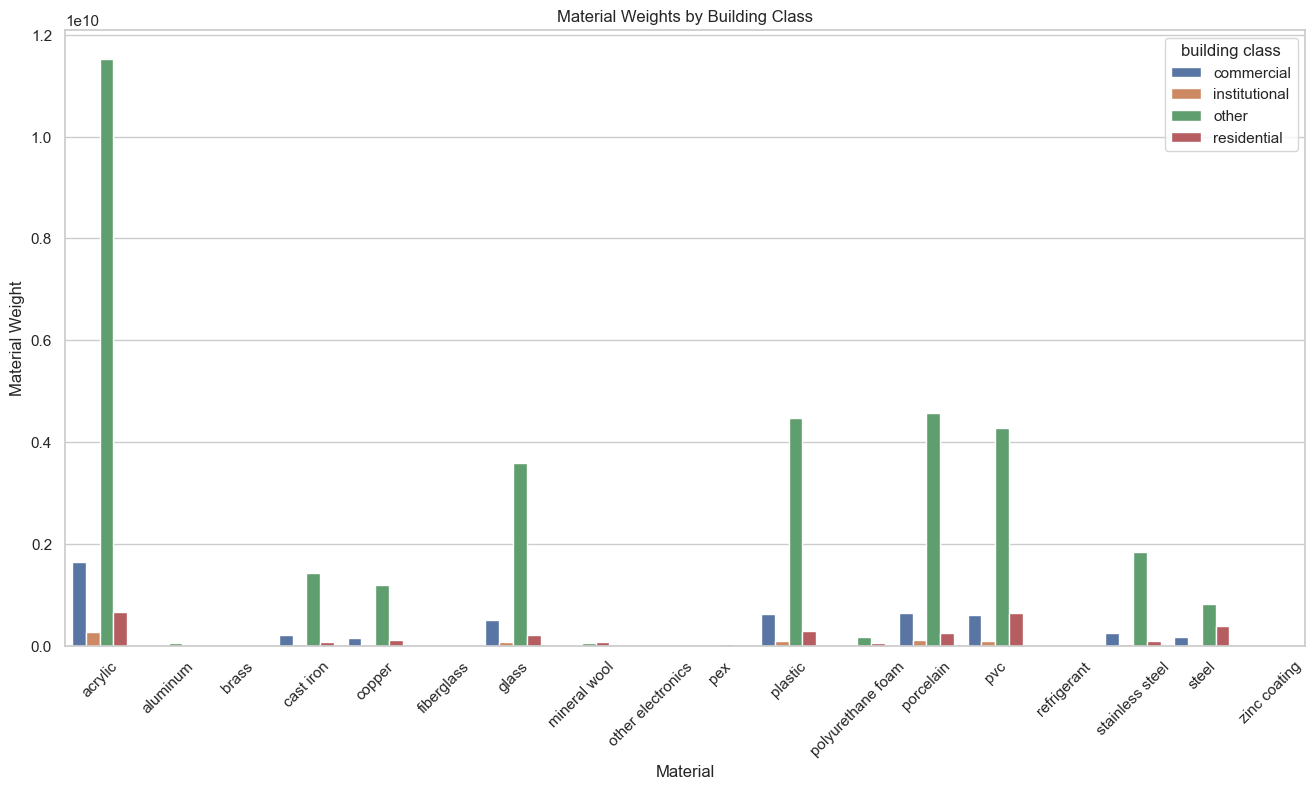

In [13]:
# plot sankey diagram 
import matplotlib.pyplot as plt
from matplotlib.sankey import Sankey
# plot bar chart of material weights by building class in
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))
sns.barplot(x='material', y='material_weight', hue='building class', data=df_final_agg)
plt.xticks(rotation=45)
plt.title('Material Weights by Building Class')
plt.ylabel('Material Weight')
plt.xlabel('Material')
plt.show()


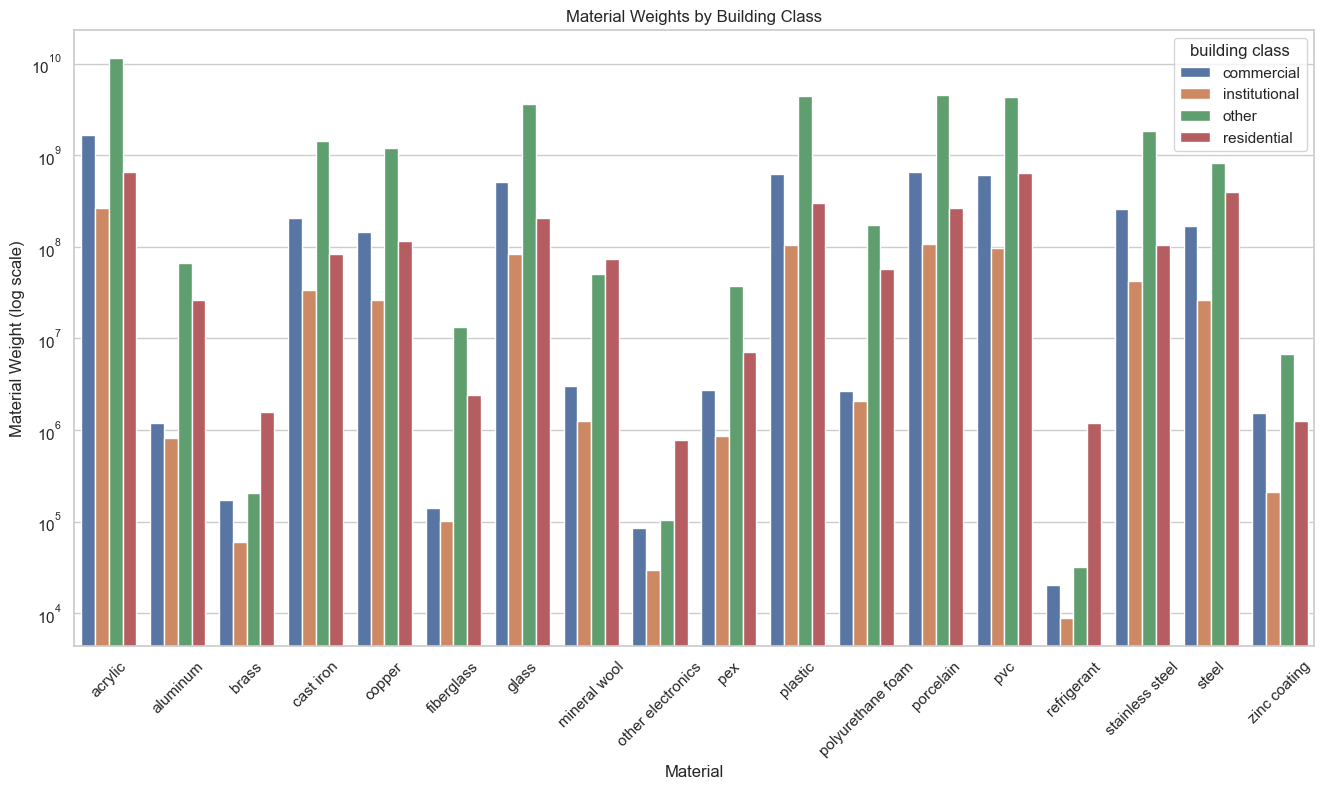

In [15]:
# plot bar chart of material weights by building class in log scale
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))
sns.barplot(x='material', y='material_weight', hue='building class', data=df_final_agg)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title('Material Weights by Building Class')
plt.ylabel('Material Weight (log scale)')
plt.xlabel('Material')
plt.show()


In [14]:
import pandas as pd
import plotly.graph_objects as go

def genSankey(df, cat_cols, value_col, title):
    # Create labels
    labels = []
    for cat in cat_cols:
        labels.extend(list(df[cat].unique()))
    labels = list(dict.fromkeys(labels))  # Remove duplicates while maintaining order

    # Create a dictionary to map labels to indices
    label_dict = {label: i for i, label in enumerate(labels)}

    # Create source and target indices
    sources = []
    targets = []
    values = []

    for i in range(len(cat_cols) - 1):
        cat1 = cat_cols[i]
        cat2 = cat_cols[i + 1]
        for j, row in df.iterrows():
            sources.append(label_dict[row[cat1]])
            targets.append(label_dict[row[cat2]])
            values.append(row[value_col])

    # Create Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=labels,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
        )
    )])

    fig.update_layout(title_text=title, font_size=10)
    return fig


# aggregate the material weights

df_agg = df_final_wt_hb.groupby(['building class', 'building system', 'component','material'],as_index=False).agg(material_weight=('material_weight','sum'))


fig = genSankey(df_agg, cat_cols=['building class', 'building system', 'component', 'material'], value_col='material_weight', title='Demo Material Flows Sankey')
config = {
    'toImageButtonOptions': {
        'format': 'svg',  # one of png, svg, jpeg, webp
        'filename': 'material_flows_sankey',
        'height': 1080,
        'width': 1920,
        'scale': 2  # Multiply title/legend/axis/canvas sizes by this factor
    }
}
fig.show(config=config)
# export offline plot
fig.write_html('D:/Github/Data/material_flows_sankey.html', auto_open=True)



In [ ]:
import pandas as pd

df = df_final
# Define component lifespan
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
    'toilet': 30,
    'shower': 20,
    'sink': 30,
    'bathtub': 30
}

# Define future decades
future_decades = [f"{2024 + i*10}-{2034 + i*10}" for i in range(5)]  # You can adjust the range as needed

# Calculate end-of-life decade
def calculate_end_of_life(row):
    lifespan = component_lifespan.get(row['component'], 0)
    return row['year of construction of the building yyyy'] + lifespan

df['end_of_life_year'] = df.apply(calculate_end_of_life, axis=1)

# Create columns for each future decade and initialize with zero
for decade in future_decades:
    df[decade] = 0

# Populate the future decade columns with material weights based on end-of-life year
for index, row in df.iterrows():
    start_year= row['year of construction of the building yyyy']
    end_year = row['end_of_life_year']
    
    for decade in future_decades:
        start, end = map(int, decade.split('-'))
        
        if start_year < end <= end_year:
            df.at[index, decade] = row['material_weight']


df.drop(columns=['year of construction of the building yyyy'], inplace=True)
# Group by future_decade and other relevant columns and sum the material weights
df_aggregated = df.groupby(['building class', 'building system', 'component', 'material','2024-2034','2034-2044','2044-2054','2054-2064','2064-2074']).agg({'material_weight': 'sum'}).reset_index()
df_aggregated

In [ ]:
import pandas as pd

df = df_final
# Define component lifespan
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
    'toilet': 30,
    'shower': 20,
    'sink': 30,
    'bathtub': 30
}

# Define future decades
future_decades = [f"{2024 + i*10}-{2034 + i*10}" for i in range(5)]  # You can adjust the range as needed

# Calculate end-of-life decade
def calculate_end_of_life(row):
    lifespan = component_lifespan.get(row['component'], 0)
    return row['year of construction of the building yyyy'] + lifespan

df['end_of_life_year'] = df.apply(calculate_end_of_life, axis=1)

# Create columns for each future decade and initialize with zero
for decade in future_decades:
    df[decade] = 0

# Populate the future decade columns with material weights based on end-of-life year
for index, row in df.iterrows():
    start_year= row['year of construction of the building yyyy']
    end_year = row['end_of_life_year']
    
    for decade in future_decades:
        start, end = map(int, decade.split('-'))
        
        if start_year < end <= end_year:
            df.at[index, decade] = row['material_weight']


df.drop(columns=['year of construction of the building yyyy'], inplace=True)
# Group by future_decade and other relevant columns and sum the material weights
df_aggregated = df.groupby(['building class', 'building system', 'component', 'material','2024-2034','2034-2044','2044-2054','2054-2064','2064-2074']).agg({'material_weight': 'sum'}).reset_index()
df_aggregated
import matplotlib.pyplot as mat

# Melt the dataframe to
df_melted = df_aggregated.melt(id_vars=['building class', 'building system', 'component', 'material'], 
                               value_vars=future_decades, 
                               var_name='Decade', 
                               value_name='Material Weight')

# Plot the bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='Decade', y='Material Weight', hue='material', data=df_melted)
plt.title('Future Availability of Materials by Decade')
plt.ylabel('Material Weight')
plt.xlabel('Decade')
plt.xticks(rotation=45)
plt.legend(title='Material',= bbox_to_anchor'Material',= bbox_to_anchor(
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()1.05,= 1), loc(1.05,= 1),'upper loc left')='upper left')
df_melted have = df_aggregated.melt(id_vars= a['buildin
plt.ylabel('Material Weight')
plt.xlabel('Decade')
plt.xticks(rotation=45)g c
                               var_name='Decade', 
plt.title('Future Availability of Materials by Decade')

sns.barplot(x='Decade', y='Material Weight', hue='material', data=df_melted)
plt.figure(figsize=(14, 8))
# Plot the bar chart                               value_name='Material Weight')
lass', long 'building system', 'component', f
                               value_vars=future_decades, ormat 'material'],  suitable for bar plot

# Melt the dataframe to have a long format suitable for bar plotplotlib.pyplot plt as plt

SyntaxError: unmatched ')' (3702947371.py, line 67)

In [ ]:
# export the final dataframe to csv in a typicaL path
df_aggregated.to_csv('/media/shuyan/Local Disk (D:)/Github/Data/final_data_aggregated.csv', index=False)

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Melt the dataframe to long format
df_melted = df_aggregated.melt(id_vars=['building class', 'building system', 'component', 'material'], 
                               var_name='decade', value_name='material_weight')

# Shift the decades to represent transitions
df_melted['next_decade'] = df_melted.groupby(['building class', 'building system', 'component', 'material'])['decade'].shift(-1)
df_melted.dropna(inplace=True)  # Drop rows where next_decade is NaN
df_melted['next_decade'] = df_melted['next_decade'].astype(str)

# Combine material and decades for unique labels in Sankey
df_melted['source'] = df_melted['material'] + '_' + df_melted['decade']
df_melted['target'] = df_melted['material'] + '_' + df_melted['next_decade']

# Remove self-references
df_melted = df_melted[df_melted['source'] != df_melted['target']]

# Define the Sankey generation function
def genSankey(df, source_col, target_col, value_col, title):
    # Create labels
    labels = list(set(df[source_col].unique()).union(set(df[target_col].unique())))
    
    # Create a dictionary to map labels to indices
    label_dict = {label: i for i, label in enumerate(labels)}

    # Map source and target labels to indices
    df['source_id'] = df[source_col].apply(lambda x: label_dict[x])
    df['target_id'] = df[target_col].apply(lambda x: label_dict[x])

    # Create the Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=labels,
        ),
        link=dict(
            source=df['source_id'],
            target=df['target_id'],
            value=df[value_col],
        )
    )])

    fig.update_layout(title_text=title, font_size=10)
    return fig

# Generate the Sankey diagram
fig = genSankey(df_melted, source_col='source', target_col='target', value_col='material_weight', title='Future Availability of Material Flows by Decade')

# Configurations for exporting
config = {
    'toImageButtonOptions': {
        'format': 'svg',  # one of png, svg, jpeg, webp
        'filename': 'material_flows_by_decade',
        'height': 1080,
        'width': 1920,
        'scale': 2  # Multiply title/legend/axis/canvas sizes by this factor
    }
}

# Show the figure with the given configuration
fig.show(config=config)

## Combined Sankey Diagram

In [ ]:
import pandas as pd
import plotly.graph_objects as go
df = df_final

# Define component lifespan
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define future decades
future_decades = [f"{2024 + i*10}-{2034 + i*10}" for i in range(5)]  # You can adjust the range as needed
# Calculate end-of-life decade
def calculate_end_of_life(row):
    lifespan = component_lifespan.get(row['component'], 0)
    return row['year of construction of the building yyyy'] + lifespan

df['end_of_life_year'] = df.apply(calculate_end_of_life, axis=1)
# Define a function to create decade columns
def assign_decade(year):
    if year >= 2024 and year < 2034:
        return '2024-2034'
    elif year >= 2034 and year < 2044:
        return '2034-2044'
    elif year >= 2044 and year < 2054:
        return '2044-2054'
    elif year >= 2054 and year < 2064:
        return '2054-2064'
    elif year >= 2064 and year < 2074:
        return '2064-2074'
    else:
        return 'before 2024'

# Apply function to create the decade column
df['end_of_life_decade'] = df['end_of_life_year'].apply(assign_decade)
# Group by future_decade and other relevant columns and sum the material weights
df_aggregated = df.groupby(['building class', 'building system', 'component', 'material','end_of_life_decade']).agg({'material_weight': 'sum'}).reset_index()

df= df_aggregated
# Prepare the data for the Sankey diagram
# We need to create lists of unique labels for nodes and a way to map them to the source and target of links

# Create unique lists of labels
building_category = df['building class'].unique().tolist()
building_system = df['building system'].unique().tolist()
component = df['component'].unique().tolist()
material = df['material'].unique().tolist()
end_of_life_decade = df['end_of_life_decade'].unique().tolist()

labels = building_category + building_system + component + material + end_of_life_decade

# Create mappings from labels to indices
label_to_index = {label: index for index, label in enumerate(labels)}

# Create source and target lists for the Sankey diagram
source = []
target = []
value = []

# Mapping building category to building system
for _, row in df.iterrows():
    source.append(label_to_index[row['building class']])
    target.append(label_to_index[row['building system']])
    value.append(row['material_weight'])

# Mapping building system to component
for _, row in df.iterrows():
    source.append(label_to_index[row['building system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Mapping component to material
for _, row in df.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Mapping material to end of life decade
for _, row in df.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['end_of_life_decade']])
    value.append(row['material_weight'])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Building Material Flow Sankey Diagram", font_size=10)
fig.show()


# **Add Reuse/Recycle/Refurbish/Disposal post flows**

In [ ]:
import pandas as pd

# Sample data
data = {
    "year_of_construction": [1530.0, 1530.0, 1530.0, 1530.0, 1530.0, 2021.0, 2021.0, 2021.0, 2021.0, 2021.0],
    "building_class": ["housing"]*10,
    "building_system": ["electrical system", "electrical system", "heating system", "heating system", "heating system", "plumbing system", "plumbing system", "plumbing system", "plumbing system", "plumbing system"],
    "sub_system": ["electrical wiring and cables", "electrical wiring and cables", "heating", "heating", "heating", "drainage and waste pipes", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures"],
    "component": ["electrical cable", "electrical cable", "boiler", "boiler", "boiler", "water pipe", "water pipe", "water pipe", "water pipe", "water pipe"],
    "material": ["copper", "pvc", "aluminum", "brass", "copper", "zinc coating", "copper", "pex", "steel", "zinc coating"],
    "material_weight": [0.002017, 0.078648, 1.030000, 1.030000, 5.150000, 0.000000, 0.000000, 16.050662, 0.000000, 0.000000]
}

df = pd.DataFrame(data)

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        row['reuse'] = reuse / total
        row['recycle'] = recycle / total
        row['refurbish'] = refurbish / total
        row['disposal'] = disposal / total
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

df


In [ ]:
import pandas as pd
import plotly.graph_objects as go


# df = pd.DataFrame(data)
df = df_final
# rename column
df.rename(columns={'year of construction of the building yyyy': 'year_of_construction'}, inplace=True)
# add _ to column names
df.columns = [col.replace(' ', '_') for col in df.columns]

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        if total > 0:
            row['reuse'] = reuse / total
            row['recycle'] = recycle / total
            row['refurbish'] = refurbish / total
            row['disposal'] = disposal / total
        else:
            row['reuse'] = 0
            row['recycle'] = 0
            row['refurbish'] = 0
            row['disposal'] = 1
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

# Calculate end-of-life year
def calculate_end_of_life(row):
    lifespan = component_lifespan.get(row['component'], 0)
    return row['year_of_construction'] + lifespan

df['end_of_life_year'] = df.apply(calculate_end_of_life, axis=1)

# Define a function to create decade columns
def assign_decade(year):
    if year >= 2024 and year < 2034:
        return '2024-2034'
    elif year >= 2034 and year < 2044:
        return '2034-2044'
    elif year >= 2044 and year < 2054:
        return '2044-2054'
    elif year >= 2054 and year < 2064:
        return '2054-2064'
    elif year >= 2064 and year < 2074:
        return '2064-2074'
    else:
        return 'before 2024'

# Apply function to create the decade column
df['end_of_life_decade'] = df['end_of_life_year'].apply(assign_decade)

# Group by future_decade and other relevant columns and sum the material weights
df_aggregated = df.groupby(['building_class', 'building_system', 'component', 'material', 'end_of_life_decade']).agg({'material_weight': 'sum', 'reuse': 'mean', 'recycle': 'mean', 'refurbish': 'mean', 'disposal': 'mean'}).reset_index()

# Generate the reuse/recycle flows for each component and material
flows = []
for _, row in df_aggregated.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[category]
        flows.append(flow)

df_flows = pd.DataFrame(flows)

# Aggregate flows by end-of-life decade and category
df_flows_aggregated = df_flows.groupby(['end_of_life_decade', 'category']).agg({'weight': 'sum'}).reset_index()

# Prepare the data for the Sankey diagram
# We need to create lists of unique labels for nodes and a way to map them to the source and target of links

# Create unique lists of labels
building_category = df['building_class'].unique().tolist()
building_system = df['building_system'].unique().tolist()
component = df['component'].unique().tolist()
material = df['material'].unique().tolist()
end_of_life_decade = df['end_of_life_decade'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + component + material + end_of_life_decade + categories

# Create mappings from labels to indices
label_to_index = {label: index for index, label in enumerate(labels)}

# Create source and target lists for the Sankey diagram
source = []
target = []
value = []

# Mapping building category to building system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# Mapping building system to component
for _, row in df.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Mapping component to material
for _, row in df.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Mapping material to end of life decade
for _, row in df.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['end_of_life_decade']])
    value.append(row['material_weight'])

# Mapping end of life decade to categories
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['end_of_life_decade']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Building Material Flow Sankey Diagram", font_size=10)
fig.show()



In [ ]:
import pandas as pd
import plotly.graph_objects as go

# df = pd.DataFrame(data)
df = df_final
# rename column
df.rename(columns={'year of construction of the building yyyy': 'year_of_construction'}, inplace=True)
# add _ to column names
df.columns = [col.replace(' ', '_') for col in df.columns]

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        if total > 0:
            row['reuse'] = reuse / total
            row['recycle'] = recycle / total
            row['refurbish'] = refurbish / total
            row['disposal'] = disposal / total
        else:
            row['reuse'] = 0
            row['recycle'] = 0
            row['refurbish'] = 0
            row['disposal'] = 1
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

# Generate the reuse/recycle flows for each component and material
flows = []
for _, row in df.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[category]
        flows.append(flow)

df_flows = pd.DataFrame(flows)

# Aggregate flows by building class, building system, sub system, component, material, and category
df_flows_aggregated = df_flows.groupby(['building_class', 'building_system', 'sub_system', 'component', 'material', 'category']).agg({'weight': 'sum'}).reset_index()

# Prepare the data for the Sankey diagram
# We need to create lists of unique labels for nodes and a way to map them to the source and target of links

# Create unique lists of labels
building_category = df['building_class'].unique().tolist()
building_system = df['building_system'].unique().tolist()
sub_system = df['sub_system'].unique().tolist()
component = df['component'].unique().tolist()
material = df['material'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + sub_system + component + material + categories

# Create mappings from labels to indices
label_to_index = {label: index for index, label in enumerate(labels)}

# Create source and target lists for the Sankey diagram
source = []
target = []
value = []

# Mapping building category to building system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# Mapping building system to sub system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['sub_system']])
    value.append(row['material_weight'])

# Mapping sub system to component
for _, row in df.iterrows():
    source.append(label_to_index[row['sub_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Mapping component to material
for _, row in df.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Mapping material to categories
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Building Material Flow Sankey Diagram", font_size=10)
fig.show()
